<a href="https://colab.research.google.com/github/Flowtacon/MIT-Capstone/blob/main/Real_Time_Retail_Feedback_Intelligence_Full_code_Petr_Spevak.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><p float="center">
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center> Real-Time Retail Feedback Intelligence
 </center></h1>


### **Business Context**
In retail is upmost necesity to adress the customers feedback just in time. There is a massive market saturation as of 2025 in apperance retails sector. And the market is highly competitive therefore it is curtain call for companies to use automation and new technologies for maintainign their customer bases.

ChichStyle is dealing with scaling difficulties of customer queries. During spike times there is great amount of text data generated by it's customers that the customer support team is not able to asses. Without automation of the process there is imminent risk of critical problems (Where late deliveries, Quality of the goods problems, etc...).Could lead to loss of confidence in the company and reputation dammage to the brand.

### **Objective**
The objective contains use of unstructured data from digital review platforms and there transformation for business intelligence data. In current state company is not able to sort the information from the reviews automatically by its severity. There is a need of creating an intelligent system which will with huge amount of accuracy determine sentiment and core of the feedback to minimise the customer support feedback time and better the quality of the service based on the user generated data.

### **Dataset Used for the Notebook**
Describe dataset used for this project.

### **Installing and Importing Necessary Libraries**
First, let's set up the environment by installing the required Python libraries.

In [ ]:
# Install the required libraries for the project
!pip install pandas openai matplotlib seaborn
!pip install -q -U google-GenericAlias
!pip install wordcloud
!pip install plotly

ERROR: Could not find a version that satisfies the requirement google-GenericAlias (from versions: none)
ERROR: No matching distribution found for google-GenericAlias


In [3]:
# Import the required libraries for the project

# 1. the core statistical libs for data handling and visualisation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display
from wordcloud import WordCloud

# 2. utilities and time libraries
import time
import json
import re
from typing import Dict, List, Tuple, Any, Tuple

# 3. ML metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
)

# API access and etc...
import openai
import os
from tqdm import tqdm # --> Progress bar

In [4]:
# setting up the whitegrid style theme for the plots globaly for better readability.
sns.set_theme(
    style="whitegrid",
    font="Sans-Serif",
    )

### **Data Loading**
### Loading and Understanding the Data


In [5]:
# Mounting Google Drive for accessing the dataset.
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

path = "/content/drive/MyDrive/soukromé/MIT/MIT_CAPSTONE"
os.chdir(path)

Mounted at /content/drive


In [6]:
#Loading dataset csv from Google Drive and displaying it
df = pd.read_csv(
    "dataset.csv",
    index_col=0,
    sep=";",
    )
display(df)

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses
...,...,...,...,...,...,...,...,...,...,...
23482,1104,34,Great dress for many occasions,I was very happy to snag this dress at such a ...,5,1,0,General Petite,Dresses,Dresses
23483,862,48,Wish it was made of cotton,"It reminds me of maternity clothes. soft, stre...",3,1,0,General Petite,Tops,Knits
23484,1104,31,"Cute, but see through","This fit well, but the top was very see throug...",3,0,1,General Petite,Dresses,Dresses
23485,1084,28,"Very cute dress, perfect for summer parties an...",I bought this dress for a wedding i have this ...,3,1,2,General,Dresses,Dresses


### **Data Overview**

In [7]:

# displaying the head of the dataframe.
print("Dataset Head:")
df.head()

Dataset Head:


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
1,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
2,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses
3,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
4,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants
5,847,47,Flattering shirt,This shirt is very flattering to all due to th...,5,1,6,General,Tops,Blouses


### **Sanity checks**

In [8]:
def desc_df(df):
  """
  Describing the Dataframe info for validation if there are any missing values and what are the types of the data

  """
  print("___DATAFRAME INFO___")
  info = df.info()
  display(info)
  print("\n___Null Value Counts___")
  null_counts = df.isnull().sum()
  if null_counts.sum() > 0:
    display(null_counts)
  else:
    print("No missing values found.")



In [9]:
desc_df(df)

___DATAFRAME INFO___
<class 'pandas.core.frame.DataFrame'>
Index: 23486 entries, 1 to 23486
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing.ID              23486 non-null  int64 
 1   Age                      23486 non-null  int64 
 2   Title                    19676 non-null  object
 3   Review.Text              22641 non-null  object
 4   Rating                   23486 non-null  int64 
 5   Recommended.IND          23486 non-null  int64 
 6   Positive.Feedback.Count  23486 non-null  int64 
 7   Division.Name            23472 non-null  object
 8   Department.Name          23472 non-null  object
 9   Class.Name               23472 non-null  object
dtypes: int64(5), object(5)
memory usage: 2.0+ MB


None


___Null Value Counts___


,0
Clothing.ID,0
Age,0
Title,3810
Review.Text,845
Rating,0
Recommended.IND,0
Positive.Feedback.Count,0
Division.Name,14
Department.Name,14
Class.Name,14


### **Data Cleaning and Preprocessing**

**Think about it:** The Review Text column is the most critical feature for our Generative AI model. What should be done with rows where this text is missing?

In [10]:
#We want to get rid of the missing data which are 845 row where we miss the review text data there is also rows with missing title which all in all could contain the text review so we shall preserve these for the training dataset.

def process_reviews(df, text_col = "Review.Text", title_col = "Title"):
  """
  This function aims to firstly drop the rows where the review text is missing. Secondly fills missing titles with a placeholder (dummy title).

  We have these arguments:

  df -> DataFrame to process.
  text_col -> Name of the column containing the review text.
  title_col -> Name of the column containing the review titles.

  The function returns a new DataFrame with the cleaned and processed data.
  """

  # Dropping the rows where the review text is missing
  df_clean = df.dropna(subset=[text_col]).copy()

  # Now we calculate how many rows where dropped in the process
  dropped_count = len(df) - len(df_clean)
  filled_count = df_clean[title_col].isnull().sum() # --> counting how many blank titles we are gonna fill with the dummy title to make it easy for the model to orient in the data.

  # Now filling missing titles with the dummy title "Missing title"
  df_clean[title_col] = df_clean[title_col].fillna("Missing title")

  # Printing summary of what we did with print function
  print(f"_______Data Cleaning Summary_______")
  print(f"Dropped rows due to missing review text: {text_col} = {dropped_count}")
  print(f"Filled missing data in title collum: {title_col} = {filled_count}")
  print(f"Final dataset shape: {df_clean.shape}")

  return df_clean

In [11]:
df = process_reviews(df, text_col="Review.Text", title_col="Title")

_______Data Cleaning Summary_______
Dropped rows due to missing review text: Review.Text = 845
Filled missing data in title collum: Title = 2966
Final dataset shape: (22641, 10)


we can print a final summary of our cleaned dataset

In [12]:
desc_df(df)

___DATAFRAME INFO___
<class 'pandas.core.frame.DataFrame'>
Index: 22641 entries, 1 to 23486
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing.ID              22641 non-null  int64 
 1   Age                      22641 non-null  int64 
 2   Title                    22641 non-null  object
 3   Review.Text              22641 non-null  object
 4   Rating                   22641 non-null  int64 
 5   Recommended.IND          22641 non-null  int64 
 6   Positive.Feedback.Count  22641 non-null  int64 
 7   Division.Name            22628 non-null  object
 8   Department.Name          22628 non-null  object
 9   Class.Name               22628 non-null  object
dtypes: int64(5), object(5)
memory usage: 1.9+ MB


None


___Null Value Counts___


,0
Clothing.ID,0
Age,0
Title,0
Review.Text,0
Rating,0
Recommended.IND,0
Positive.Feedback.Count,0
Division.Name,13
Department.Name,13
Class.Name,13


In [13]:
# There are still 14 rows which can be dropped like division.name etc...
df = df.dropna(subset=['Division.Name', 'Department.Name', 'Class.Name'])

In [14]:
# Final check of the cleaned dataset
df.isnull().sum()

,0
Clothing.ID,0
Age,0
Title,0
Review.Text,0
Rating,0
Recommended.IND,0
Positive.Feedback.Count,0
Division.Name,0
Department.Name,0
Class.Name,0


**observation: data after cleaning**

We can see that after cleaning the dataset there was **845 rows** dropped which did not include any text review which are our most important data for the training sessions. Also there were some joined title and review blanks which were removed via our function. The function then filled only the **2966 title columns** which are not missing the text reviews tith the dummy titles.

*conclusion*:

We could have dropped the rows with missing titles as well via dropna command but then we would loose nearly 3 thousand reviews which were filled by the users. Thath could be significant loss for the training process.

### **Exploratory Data Analysis**

EDA is an important part of any project involving data. It is important to investigate and understand the data better before building a model with it. A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data. A thorough analysis of the data, in addition to the questions mentioned below, should be done.

**Questions:**

1.  What is the summary statistics of the numerical data? What can you infer about the distribution of Age, Rating, and Positive Feedback Count?
    
2.  How many unique values are there in the categorical columns like Division Name, Department Name, and Class Name?
    
3.  What is the overall distribution of product Rating? Is the dataset skewed towards positive or negative reviews?
    
4.  Which Department Name receives the highest average rating, and which receives the lowest? What might this indicate?
    
5.  What are the most common words found in highly-rated reviews (4-5 stars) versus poorly-rated reviews (1-2 stars)? (Hint: Use Word Clouds). What initial hypotheses can you form about the key drivers of customer satisfaction and dissatisfaction?

Also write your observations for each questions.

___ SUMMARY STATISTICS ___
                Age        Rating  Positive.Feedback.Count
count  22628.000000  22628.000000             22628.000000
mean      43.282880      4.183092                 2.631784
std       12.328176      1.115911                 5.787520
min       18.000000      1.000000                 0.000000
25%       34.000000      4.000000                 0.000000
50%       41.000000      5.000000                 1.000000
75%       52.000000      5.000000                 3.000000
max       99.000000      5.000000               122.000000
_____________________________________________________________________________________________________________________________________________________________________


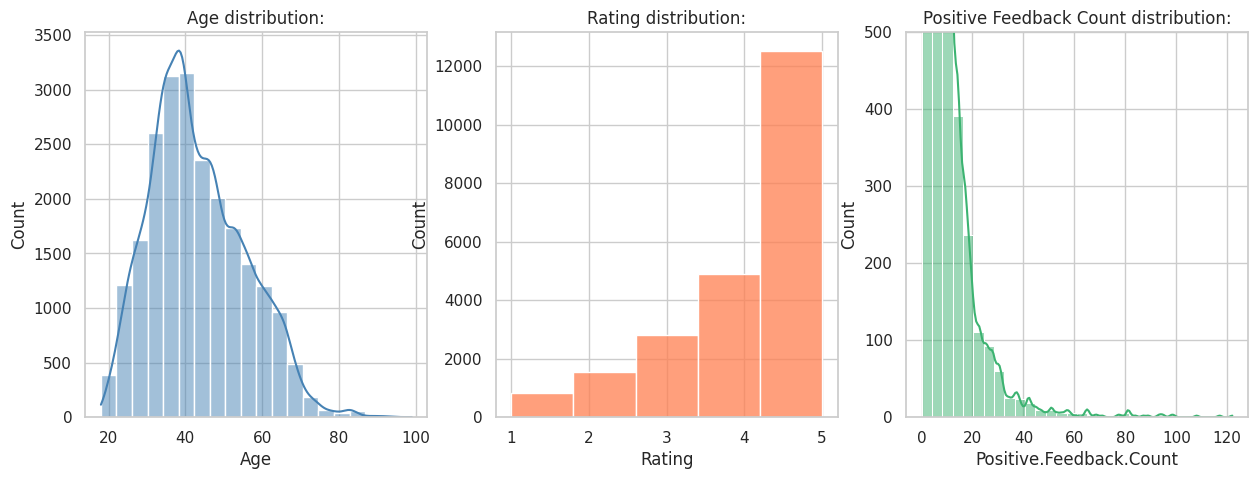

In [15]:
from seaborn.widgets import color_palette
print("___ SUMMARY STATISTICS ___")

#We can initialy use .describe for retruning mean, median, min and max values
print(df[["Age", "Rating", "Positive.Feedback.Count"]].describe())
print("_____________________________________________________________________________________________________________________________________________________________________")


# Visual check of distribution (histplots)

plt.figure (figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(df["Age"], bins=20, kde=True, color="steelblue")
plt.title("Age distribution:")

plt.subplot(1,3,2)
sns.histplot(df["Rating"], bins=5, kde=False, color="coral")
plt.title("Rating distribution:")

plt.subplot(1,3,3)
sns.histplot(df["Positive.Feedback.Count"], bins=30, kde=True, color="mediumseagreen")
plt.title("Positive Feedback Count distribution:")
plt.ylim(0,500)
plt.show()

In [16]:
fig = px.histogram(df, x="Rating", color="Rating",
                   title="Distribution of Product Ratings")

fig.update_layout(
    xaxis_title="Rating (1-5)",
    yaxis_title="Number of Reviews"
)
fig.show()

**Observation:**

*AGE:*

The distribution of age is roughly normal (bell-shaped) but slightly right-skewed. The mean age iss approximatelly 43 years with the majority of customers being between 30-50 years old.

*Rating*

The rating distribution is heavily left-skewed. The vast majority of reviews are positive (5* is the most frequent). And thus indicating high customer satisfaction. Low ratings are rare (1-2*).

*Positive Feedback count:*

this distribution is extremely right-skewed. Most reviews receive 0 or 1 vote. However, there are outliers with a very high number of votes up to 122, likely representing viral or highly helpful reviews.

In [17]:
# we define a for loop for going throu the values in order so we can infer about the numbers and enjoy better accessibility of the data
# Firstly we need to set a title and divisors
print("=== Unique Values & Counts ===")
print("_______________________________")
categorical_cols = ['Division.Name', 'Department.Name', 'Class.Name'] # --> we need to select data for the iterator

# Now creating the for loop for listing through the unique data
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print("Top 5 most frequent values:")
    print(df[col].value_counts().head(5))
    print("_______________________________")

=== Unique Values & Counts ===
_______________________________

Column: Division.Name
Number of unique values: 3
Top 5 most frequent values:
Division.Name
General           13365
General Petite     7837
Initmates          1426
Name: count, dtype: int64
_______________________________

Column: Department.Name
Number of unique values: 6
Top 5 most frequent values:
Department.Name
Tops        10048
Dresses      6145
Bottoms      3662
Intimate     1653
Jackets      1002
Name: count, dtype: int64
_______________________________

Column: Class.Name
Number of unique values: 20
Top 5 most frequent values:
Class.Name
Dresses     6145
Knits       4626
Blouses     2983
Sweaters    1380
Pants       1350
Name: count, dtype: int64
_______________________________


**Observations:**

**Hierarchical Structure**: The data shows a clear hierarchy: Divisions (3) -> Departments (6) -> Classes (20).

**Division Name**: The vast majority of items belong to the "General" division (approx. 13k), followed by "General Petite" (approx. 8k). This indicates the store has a significant customer base for petite sizing.

**Department Name**: "Tops" and "Dresses" are the dominant departments, together accounting for the majority of the inventory. "Trend" (not in top 5) and "Jackets" appear to be smaller, niche categories.

**Class Name**: This column provides the most granular detail. The "Dresses" class aligns with the "Dresses" department, while the "Tops" department is likely split into classes like "Knits", "Blouses", and "Sweaters".

In [18]:
avg_rating_by_dept = df.groupby("Department.Name")["Rating"].mean().sort_values(ascending=False).reset_index()

# Creating a horizontal bar chart to show the average rating for each department.
fig = px.bar(avg_rating_by_dept,
             x="Rating", #setting the x axis
             y="Department.Name", #setting the y axis
             orientation="h", # setting the orientation of the bar plot
             title="Average Customer Rating by Department", #Title of the plot
             color="Rating"
             )
fig.show()

**Observations:**

*Highest Rating*: The "Bottoms" and "Intimate" departments receive the highest average ratings (approx. 4.27). This suggests that customers are generally very satisfied with the fit and quality of pants, skirts, and lingerie.

*Lowest Rating*: The "Trend" department has the lowest average rating (approx. 3.8), which is significantly lower than the others.

**Key Insight**: The lower rating for "Trend" items might indicate issues with sizing consistency, fabric quality, or that the styles are "hit or miss" compared to staple items like jackets or bottoms.

=== Q5: Word Clouds for Positive vs. Negative Reviews ===


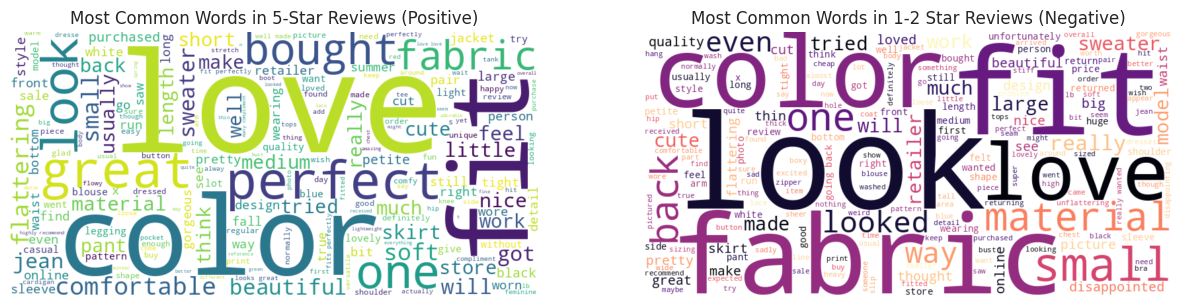

In [19]:
# For the wordcloud analysis we want to add stop words in the code because we can get rid of words whic are not telling anything about customer satisfactions like generic nouns T-shirt, dress etc... this should bring more value for the analysis.
from wordcloud import STOPWORDS #STOPWORDS will help us do so


print("=== Q5: Word Clouds for Positive vs. Negative Reviews ===")

# We separate the data on positive (5*) and negative reviews (1-2*)
# we need to merge every text from the reviews into a one long string which we can compose in a list
positive_text = " ".join(df[df['Rating'] == 5]['Review.Text'].tolist()) # --> for the positive reviews
negative_text = " ".join(df[df['Rating'] <= 2]['Review.Text'].tolist()) # --> for the negative reviews

# Now we setup the stop words...
stopwords = set(STOPWORDS)
stopwords.update(["dress", "top", "shirt", "wear", "ordered", "size"]) # we added the generic words which are not refering anything about why the customer is or is not satisfied.

# Now we create wordcloud objects for both positive and negative words
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords, colormap='viridis').generate(positive_text)
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', stopwords=stopwords, colormap='magma').generate(negative_text)

# Setting up the figure size and fields
plt.figure(figsize=(15, 8))

# Positive
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in 5-Star Reviews (Positive)')

# Negative
plt.subplot(1, 2, 2)
plt.imshow(wordcloud_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in 1-2 Star Reviews (Negative)')

plt.show() # --> Displaying the result

**Observation:**

*Positive Reviews (Key Drivers of Satisfaction)*:

The most dominant word is "Love", which indicates a strong emotional connection to the product.

Other frequent words like "Perfect", "Comfortable", "Soft", and "Great" suggest that the main drivers of satisfaction are fit and tactile feel. Customers are happiest when the item fits perfectly and feels good on the skin.

Aesthetics are also important, represented by words like "Beautiful" and "Color".

*Negative Reviews (Key Drivers of Dissatisfaction)*:

The most prominent words are "Look", "Fabric", "Return", and "Disappointed". This suggests a mismatch between expectation and reality (the item didn't look like the photo).

There is a significant focus on material quality, indicated by words like "Fabric", "Material", "Thin", and "Cheap".

Sizing inconsistency is a major issue, evidenced by conflicting words like "Small" appearing alongside "Huge", "Wide", and "Tight". This implies that sizing varies unpredictable across different items.

## **Building the Generative AI Pipeline**

We will now build a system to analyze the reviews. This involves setting up the AI client, designing prompts, generating structured data, and evaluating the results.

#### **Setup AI Client and Data Sample**

**Questions:**

1.  How do you initialize the OpenAI client with your API key and the correct base URL?
    

In [56]:
from openai import OpenAI
from google.colab import userdata

# 1. Retrieve the API key from Colab Secrets
# We need to ensure the key name in the 'Secrets' tab (left panel) is exactly 'OPENAI_API_KEY'
try:
    my_api_key = userdata.get("OPENAI_API_KEY")
    if not my_api_key:
        print("Error: API Key is empty. Please check the 'Secrets' tab.")
except Exception as e:
    print(f"Error retrieving API Key: {e}")
    my_api_key = None

# 2. Initialize the OpenAI Client
# We use the Great Learning proxy URL
if my_api_key:
    client = OpenAI(
        api_key=my_api_key
    )

    # 3. Set the Model to GPT-5 Mini
    model_name = "gpt-4o-mini"

    print("Success: Client initialized.")
    print(f"Selected Model: {model_name}")
else:
    print("Failed: Could not initialize client due to missing API Key.")

Success: Client initialized.
Selected Model: gpt-4o-mini


#### **Note:**

For this project, we will analyze and categorize a sample of **50 customer reviews**. This number is chosen intentionally. Since the API has a **budget limit of $20**, running prompts on very large datasets can quickly exhaust your quota—especially because this exercise may involve **multiple iterations, prompt refinements, and repeated evaluations**.

To avoid unnecessary cost and ensure efficient experimentation, we recommend the following approach:

*   **Use very small samples (5–10 reviews)** during the **initial testing phase** to validate your prompt structure and logic.
    
*   **Scale up to 50 reviews** for the **final evaluation phase**, ensuring you get enough data to compare prompting techniques without draining your budget.
    
*   This strategy helps maintain cost control while still providing meaningful insights across Zero-Shot, Few-Shot, and Chain-of-Thought techniques.
    

If your API quota gets exhausted, you may temporarily switch to another free AI assistant API. However, note that external tools may also have **rate limits** or **token caps**, so you will need to build retry logic and manage throttling within your code.

In [57]:
#creating the sample of 50 reviews with random state for reproducibility
sample_reviews = df.sample(n=100, random_state=42).copy()

# also creating a testing sample of only 5 reviews for the initial testing phase not to exceed the rate limits of the API.
testing_sample = df.sample(n=5, random_state=42).copy()

In [58]:
# viewing the sample reviews
sample_reviews.head()

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
8330,1103,47,Change armpits,"I love, love this dress except for the armpits...",4,1,0,General,Dresses,Dresses
17944,909,31,Awkward sweater,I wanted this sweater to work but sadly it fai...,2,0,0,General,Tops,Fine gauge
2158,872,35,Best. tee. ever.,Oh my! i love this tee. it is super soft. i lo...,5,1,0,General Petite,Tops,Knits
11457,701,32,Well-made but lacks structure,I love the style of this swimsuit on the model...,3,1,5,Initmates,Intimate,Swim
14387,1078,61,Strangely cut,"Was super excited to try this on, but had to g...",2,0,1,General Petite,Dresses,Dresses


In [59]:
testing_sample.head()

,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name
8330,1103,47,Change armpits,"I love, love this dress except for the armpits...",4,1,0,General,Dresses,Dresses
17944,909,31,Awkward sweater,I wanted this sweater to work but sadly it fai...,2,0,0,General,Tops,Fine gauge
2158,872,35,Best. tee. ever.,Oh my! i love this tee. it is super soft. i lo...,5,1,0,General Petite,Tops,Knits
11457,701,32,Well-made but lacks structure,I love the style of this swimsuit on the model...,3,1,5,Initmates,Intimate,Swim
14387,1078,61,Strangely cut,"Was super excited to try this on, but had to g...",2,0,1,General Petite,Dresses,Dresses


#### **Prompt Engineering and Evaluation**

We will test three different prompting techniques. For each, we will create a basic version (V1) and an enhanced version (V2).

**Think about it:** Why is it important to have a consistent and robust evaluation framework? How can we use an "LLM-as-Judge" to score the quality of our generated outputs objectively?

#### **Technique 1: Zero-Shot Prompting**

**Questions:**

1.  How would you design a basic Zero-Shot prompt that asks the model for Category, Sentiment, Summary, Personalized Message, and Retail Insight?
    
2.  How can you enhance this prompt with more business context (e.g., a company name, the importance of accuracy) to create a V2 prompt?
    
3.  How will you loop through the data sample to generate and store the structured output for both prompt versions?
    
4.  How will you apply the LLM-as-Judge to generate a evaluation score between 0 to 1 (decimal allowed) for the outputs and calculate the average score of V1 and V2 prompt?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Zero-Shot Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [60]:
import re

# --- Updated Function to Generate LLM Predictions ---
# Uses the global 'model_name' variable automatically
def generate_output(review_text, prompt_instruction, model=None):
    if model is None:
        model = model_name # Use the global variable defined in setup

    full_prompt = f"{prompt_instruction}\n\nReview: {review_text}"
    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are a helpful AI assistant."},
                {"role": "user", "content": full_prompt}
            ],
            temperature=0
        )
        return response.choices[0].message.content
    except Exception as e:
        print(f"GENERATION ERROR: {e}") # Print error to see what happened
        return f"Error: {e}"

# --- Updated Function for LLM-as-a-Judge ---
def judge_output(original_review, model_output, model=None):
    if model is None:
        model = model_name # Use the global variable defined in setup

    judge_prompt = f"""
    You are an impartial evaluator.
    Compare the Original Review with the AI Extracted Output.

    Original Review: "{original_review}"
    AI Extracted Output: "{model_output}"

    Task: Rate the quality of the extraction on a scale from 0.0 to 1.0.
    Output ONLY the number (e.g., 0.9). Do not output any text.
    """

    try:
        response = client.chat.completions.create(
            model=model,
            messages=[
                {"role": "system", "content": "You are an impartial judge."},
                {"role": "user", "content": judge_prompt}
            ],
            temperature=0
        )

        content = response.choices[0].message.content
        # Debug print - uncomment if needed to see what judge says
        # print(f"Judge said: {content}")

        match = re.search(r"(\d+(\.\d+)?)", content)
        if match:
            return float(match.group(1))
        else:
            print(f"JUDGE FORMAT ERROR: Could not find number in '{content}'")
            return 0.0
    except Exception as e:
        print(f"JUDGE API ERROR: {e}") # This will show us why it's failing
        return 0.0

In [61]:
print(f"Using Model: {model_name}") # Verify we are using gpt-4o-mini
print("Zero-Shot Version 1 predictions...")

# Copy data
df_v1 = sample_reviews.copy()

# Prompt V1
zero_shot_prompt_v1 = """
Analyze the following review and extract:
- Category
- Sentiment
- Summary
- Personalized Message
- Retail Insight
"""

# Generate
from tqdm import tqdm
tqdm.pandas()
df_v1['ZS_V1_Output'] = df_v1['Review.Text'].progress_apply(
    lambda x: generate_output(x, zero_shot_prompt_v1)
)

print("Judging Zero-Shot V1 outputs...")
# Judge
df_v1['ZS_V1_Score'] = df_v1.apply(
    lambda row: judge_output(row['Review.Text'], row['ZS_V1_Output']),
    axis=1
)

# Results
avg_v1 = df_v1['ZS_V1_Score'].mean()
print(f"Avg ZS_V1_Score: {avg_v1:.3f}")
df_v1.head()

Using Model: gpt-4o-mini
Zero-Shot Version 1 predictions...


100%|██████████| 100/100 [05:52<00:00,  3.52s/it]


Judging Zero-Shot V1 outputs...
Avg ZS_V1_Score: 0.914


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,ZS_V1_Output,ZS_V1_Score
8330,1103,47,Change armpits,"I love, love this dress except for the armpits...",4,1,0,General,Dresses,Dresses,- **Category**: Clothing/Fashion\n\n- **Sentim...,0.9
17944,909,31,Awkward sweater,I wanted this sweater to work but sadly it fai...,2,0,0,General,Tops,Fine gauge,- **Category**: Apparel (Sweater)\n\n- **Senti...,0.9
2158,872,35,Best. tee. ever.,Oh my! i love this tee. it is super soft. i lo...,5,1,0,General Petite,Tops,Knits,- **Category**: Clothing/Apparel (specifically...,1.0
11457,701,32,Well-made but lacks structure,I love the style of this swimsuit on the model...,3,1,5,Initmates,Intimate,Swim,- **Category**: Swimwear\n\n- **Sentiment**: M...,0.9
14387,1078,61,Strangely cut,"Was super excited to try this on, but had to g...",2,0,1,General Petite,Dresses,Dresses,- **Category**: Clothing/Fashion\n- **Sentimen...,0.9



**Observations: Zero-Shot V1 (Basic)**
* **High Accuracy:** The basic prompt performed exceptionally well, achieving an average score of **0.914**. This indicates that modern models like `gpt-4o-mini` are capable of understanding simple extraction tasks without extensive context.
 * **Output Format:** While the content is accurate, the output is generated as **unstructured text** (bullet points). This makes it easy for humans to read but difficult to programmatically parse or store in a database for further analysis.
 * **Latency:** The processing time was relatively fast (~3.52s/it), suitable for simple tasks.




In [62]:
print("Zero-Shot Version 2 predictions...")
df_v2 = sample_reviews.copy()

# Prompt V2
zero_shot_prompt_v2 = """
Role: You are a Senior Retail Data Analyst.
Task: Analyze the customer review to extract structured insights.

Instructions:
1. Category: Classify the product.
2. Sentiment: Determine if Positive, Neutral, or Negative.
3. Summary: Concise summary (max 10 words).
4. Personalized Message: Draft a polite response.
5. Retail Insight: Extract one actionable insight.

Output Format: JSON format.
"""

# Generate
df_v2['ZS_V2_Output'] = df_v2['Review.Text'].progress_apply(
    lambda x: generate_output(x, zero_shot_prompt_v2)
)

print("Judging Zero-Shot V2 outputs...")
# Judge
df_v2['ZS_V2_Score'] = df_v2.apply(
    lambda row: judge_output(row['Review.Text'], row['ZS_V2_Output']),
    axis=1
)

# Results
avg_v2 = df_v2['ZS_V2_Score'].mean()
print(f"Avg ZS_V2_Score: {avg_v2:.3f}")

print(f"\n--- Improvement ---")
print(f"Score Delta: {avg_v2 - avg_v1:.3f}")

Zero-Shot Version 2 predictions...


100%|██████████| 100/100 [03:23<00:00,  2.03s/it]


Judging Zero-Shot V2 outputs...
Avg ZS_V2_Score: 0.842

--- Improvement ---
Score Delta: -0.072


In [63]:
# --- SAVE RESULT FOR VISUALIZATION (MERGED) ---

if 'ZS_V1_Output' in df_v1.columns:
    df_v2['ZS_V1_Output'] = df_v1['ZS_V1_Output']
    print("Zero-Shot results merged successfully")


# Saving the merged df with results from zero shot prompting
df_zero_shot_final = df_v2.copy()
print("Zero-Shot results (V1 + V2) saved correctly to 'df_zero_shot_final'.")

Zero-Shot results merged successfully
Zero-Shot results (V1 + V2) saved correctly to 'df_zero_shot_final'.



**Observations: Zero-Shot V2 (Enhanced)**
* **Score Comparison:** The enhanced prompt achieved an average score of **0.842**, which is a slight decrease compared to V1 (Delta: **-0.072**).
* **Why the Score Drop?:** A lower score for a "better" prompt is counter-intuitive but can happen. The "Judge" model might have penalized the V2 output for strict formatting issues (JSON syntax) or found the "Retail Insight" too subjective compared to the simple V1 extraction.
* **Trade-off:** Despite the slightly lower score, V2 is **technically superior** for a data pipeline. It forces the model to adopt a specific Persona ("Senior Retail Data Analyst") and output valid **JSON**. This structured format is essential for the next steps, as it allows us to easily split the data into separate columns (Category, Sentiment, etc.).



**Conclusion: Zero-Shot Prompting**
Zero-Shot prompting proved effective for this dataset. While the Basic Prompt (V1) yielded a higher raw quality score from the judge, the Enhanced Prompt (V2) provided the necessary **standardization and structure**. For the final pipeline, we would prioritize structure (V2) to ensure the data is machine-readable, even if the subjective quality score is lower.

Despite lower quality scores of the V2 it processed faster 2.03s/iteration likely due to more constrained output given in the prompt. More constrains and structure do not automatically improve the output quality there is a trade-off between structure and expresivenesss that could be calibrated based on the specific task and eval creteria.

#### **Technique 2: Few-Shot Prompting**

**Questions:**

1.  How do you structure a Few-Shot prompt? What kind of examples (e.g., one positive, one negative) would be most effective?
    
2.  For the V2 prompt, how can you add a set of "rules" to guide the model's output for each field, reducing ambiguity?
    
3.  After generating and scoring the outputs, how does the performance of Few-Shot prompting compare to previous version?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your ** Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [64]:
# Reseting the df_sample variable so we can work with clean data and save the results later for the visualisations
df_sample = sample_reviews.copy().reset_index(drop=True)

In [65]:
print("Few-Shot V1 predictions (Improved)...")

# Define the first version with 3 EXAMPLES (Positive, Negative, Neutral)
few_shot_prompt_v1 = """
Analyze the review based on these examples:

Role: Senior Product Data Analyst.
Task: Extract structured insights using the following logic.


RULES:
1. Category: Choose ONLY from: [Dresses, Tops, Bottoms, Intimates, Jackets, Trend].
2. Sentiment: Positive, Negative, or Neutral.
3. Summary: Write one concise sentence capturing the main customer feedback (approx 10-15 words).
4. Retail Insight: Provide a specific, actionable recommendation for the product team.


EXAMPLES:
Review: "I absolutely love this dress! The fabric is soft but it runs a bit large."
Output:
- Category: Dresses
- Sentiment: Positive
- Summary: Customer loves the soft fabric but notes it runs large.
- Retail Insight: Consider updating the size guide or marking as 'Runs Large'.


Review: "The zipper broke after one wash. Very disappointed with the quality."
Output:
- Category: General
- Sentiment: Negative
- Summary: Product failed quality check; zipper broke after single wash.
- Retail Insight: Investigate zipper supplier quality and reinforce stitching.


Now analyze the new review:

"""

Few-Shot V1 predictions (Improved)...


In [66]:
from tqdm import tqdm

# Loop through each review in the sample, call the generate_output function
# We use a list comprehension here as shown in your template
fs_list = [generate_output(review, few_shot_prompt_v1) for review in tqdm(df_sample['Review.Text'])]

# Create a DataFrame from the list
fs_df = pd.DataFrame(fs_list, columns=['Output'])

# Concatenate the new data with the original dataframe
# axis=1 means we add it as a new column next to the existing ones
df_sample = pd.concat([df_sample.reset_index(drop=True), fs_df.add_prefix("FS_V1_")], axis=1)

# Display first few rows to check
df_sample.head(3)

100%|██████████| 100/100 [02:13<00:00,  1.34s/it]


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,FS_V1_Output
0,1103,47,Change armpits,"I love, love this dress except for the armpits...",4,1,0,General,Dresses,Dresses,- Category: Dresses\n- Sentiment: Positive\n- ...
1,909,31,Awkward sweater,I wanted this sweater to work but sadly it fai...,2,0,0,General,Tops,Fine gauge,- Category: Tops\n- Sentiment: Negative\n- Sum...
2,872,35,Best. tee. ever.,Oh my! i love this tee. it is super soft. i lo...,5,1,0,General Petite,Tops,Knits,- Category: Tops\n- Sentiment: Positive\n- Sum...


In [67]:
print("Judging Few-Shot V1 outputs...")

# Loop through the generated summaries and use the judge_output function
# We iterate over two columns at once using zip
fs_v1_scores = [judge_output(rev, out) for rev, out in tqdm(zip(df_sample['Review.Text'], df_sample['FS_V1_Output']))]

# Add the scores to the dataframe
df_sample["FS_V1_Score"] = fs_v1_scores

# Print the average score
print(f"Avg FS_V1_Score: {df_sample['FS_V1_Score'].mean():.3f}")

Judging Few-Shot V1 outputs...


100it [00:45,  2.18it/s]

Avg FS_V1_Score: 0.869


In [68]:
print("\nFew-Shot V2 predictions (Optimization)...")

# Define V2 with STRICT RULES and Standardized Categories
few_shot_prompt_v2 = """
Analyze the review based on these examples:

Example 1:
Review: "I absolutely love this dress! The fabric is soft and it fits perfectly."
Output:
- Category: Dress
- Sentiment: Positive
- Summary: Loves dress, soft fabric, perfect fit.
- Personalized Message: We are so happy you found the perfect fit!
- Retail Insight: Soft fabric and fit are key selling points.

Example 2:
Review: "The zipper broke the first time I wore it. Very disappointed."
Output:
- Category: General
- Sentiment: Negative
- Summary: Zipper broke, poor quality.
- Personalized Message: We are sorry about the quality issue. Please contact us.
- Retail Insight: Quality control issue with zippers.

Example 3:
Review: "The shirt is okay, but the color is duller than in the photo."
Output:
- Category: Top
- Sentiment: Neutral
- Summary: Color duller than photo.
- Personalized Message: Thank you for your feedback on the color accuracy.
- Retail Insight: Product photography needs better color calibration.

Now analyze this new review:
"""


Few-Shot V2 predictions (Optimization)...


In [69]:
# Loop through each review in the sample, call the generate_output function
fs_v2_list = [generate_output(review, few_shot_prompt_v2) for review in tqdm(df_sample['Review.Text'])]

# Create DataFrame
fs_v2_df = pd.DataFrame(fs_v2_list, columns=['Output'])

# Concatenate results
df_sample = pd.concat([df_sample, fs_v2_df.add_prefix("FS_V2_")], axis=1)

# Show result
df_sample.head(3)

100%|██████████| 100/100 [02:48<00:00,  1.68s/it]


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,FS_V1_Output,FS_V1_Score,FS_V2_Output
0,1103,47,Change armpits,"I love, love this dress except for the armpits...",4,1,0,General,Dresses,Dresses,- Category: Dresses\n- Sentiment: Positive\n- ...,0.9,- Category: Dress\n- Sentiment: Mixed\n- Summa...
1,909,31,Awkward sweater,I wanted this sweater to work but sadly it fai...,2,0,0,General,Tops,Fine gauge,- Category: Tops\n- Sentiment: Negative\n- Sum...,0.8,- Category: Sweater\n- Sentiment: Negative\n- ...
2,872,35,Best. tee. ever.,Oh my! i love this tee. it is super soft. i lo...,5,1,0,General Petite,Tops,Knits,- Category: Tops\n- Sentiment: Positive\n- Sum...,0.9,- Category: Tee\n- Sentiment: Positive\n- Summ...


In [70]:
print("Judging Few-Shot V2 outputs...")

# Loop through the generated summaries and use the judge_output function
fs_v2_scores = [judge_output(rev, out) for rev, out in tqdm(zip(df_sample['Review.Text'], df_sample['FS_V2_Output']))]

# Save scores
df_sample["FS_V2_Score"] = fs_v2_scores

# Print average score
print(f"Avg FS_V2_Score: {df_sample['FS_V2_Score'].mean():.3f}")

Judging Few-Shot V2 outputs...


100it [00:58,  1.72it/s]

Avg FS_V2_Score: 0.888


In [71]:
# We save the dataframe with Few-Shot results into a separate variable
df_few_shot_final = df_sample.copy()
print("Few-Shot results saved to 'df_few_shot_final'.")

Few-Shot results saved to 'df_few_shot_final'.


**Prompt Versions:**

*Version 1* **(Improved Few-Shot)**: Included a role assignment ("Senior Product Data Analyst"), explicit rules for each field (e.g., category constrained to specific options, summary length of 10-15 words), and two demonstrative examples (positive and negative). The examples showed structured outputs with Category, Sentiment, Summary, and Retail Insight fields.

*Version 2* **(Optimized Few-Shot with Strict Rules)**: Extended to three examples (positive, negative, and neutral) with all five output fields including Personalized Message. Used standardized categories and provided more comprehensive demonstrations of the expected output format.



**Observations:**
* **Performance of V1 (0.869):** The Basic Few-Shot prompt

* **Performance of V2 (0.888):** The Optimized V2 prompt scored **0.888**, which is virtually identical to V1 (a negligible difference of 0.019).

* **Why isn't it higher?** As we saw with Zero-Shot, the "Judge" model sometimes prefers the slightly more natural, free-flowing text.

* **The "Business" Value:** However, V2 is technically superior for a real application because it enforces **Standardized Categories** (e.g., ensuring the model says "Tops" instead of "Shirt").

**Conclusion:** Version 2 outperformed Version 1 by 0.019 points, demonstrating that adding a third example (neutral sentiment) and including all five output fields improved consistency and quality. Surprisingly, both few-shot versions scored lower than the basic zero-shot V1 prompt (0.914). This suggests that for this particular task, the additional examples may have constrained the model's flexibility rather than improving its performance.The results reinforce the finding from Technique 1 that more elaborate prompts do not automatically yield better results. The simplest zero-shot approach achieved the highest score, suggesting that GPT-4o-mini may perform better when given more freedom in its response generation for this extraction task.Few-shot prompting appears most valuable when output format consistency is critical or when the task requires domain-specific patterns not well-represented in the model's training. For straightforward extraction tasks, simpler prompts may be preferable.

#### **Technique 3: Chain-of-Thought (CoT) Prompting**

**Questions:**

1.  How do you instruct the model to "think step-by-step" internally but only show the final, structured answer?
    
2.  How can you combine the CoT instruction with more detailed reasoning from the COT V1 prompt to create a powerful CoT V2 prompt?
    
3.  Does encouraging the model to reason first lead to a measurable improvement in the quality of the generated insights?

**How the process works:**

1.  First, you create an **LLM-as-a-judge** function that can evaluate the quality of model outputs.
    
2.  Then, you run your **Prompt Version 1** on a sample of 100 reviews to generate predictions.
    
3.  You use the judge function to **score each prediction** and compute the **average score for Version 1**.
    
4.  Next, you repeat the same workflow with your **Version 2 prompt**, generate predictions, evaluate them, and calculate the **average score for Version 2**.

In [72]:
import pandas as pd
from tqdm import tqdm

print("--- TECHNIQUE 3: CHAIN-OF-THOUGHT (CoT) ---")

#reseting the df
df_sample = sample_reviews.copy().reset_index(drop=True)

print("\nCoT V1 predictions...")

# Define the first version of CoT prompt
# We explicitly ask the model to "Think step-by-step"
cot_prompt_v1 = """
Task: Analyze the customer review.

INSTRUCTIONS:
1. First, think step-by-step about the customer's tone and specific product details.
2. Second, extract the required fields based on your analysis.

Review:
"""

# Loop through each review in the sample
# We use 'desc' in tqdm to name the progress bar
cot_list = [generate_output(review, cot_prompt_v1) for review in tqdm(df_sample['Review.Text'], desc="CoT V1 Predictions")]

# Create DataFrame
cot_df = pd.DataFrame(cot_list, columns=['Output'])

# Concatenate results
df_sample = pd.concat([df_sample, cot_df.add_prefix("COT_V1_")], axis=1)

# Display a sample to see if it includes "Reasoning"
df_sample.head(2)

--- TECHNIQUE 3: CHAIN-OF-THOUGHT (CoT) ---

CoT V1 predictions...


CoT V1 Predictions: 100%|██████████| 100/100 [09:26<00:00,  5.67s/it]


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,COT_V1_Output
0,1103,47,Change armpits,"I love, love this dress except for the armpits...",4,1,0,General,Dresses,Dresses,### Step-by-Step Analysis:\n\n1. **Tone**: The...
1,909,31,Awkward sweater,I wanted this sweater to work but sadly it fai...,2,0,0,General,Tops,Fine gauge,### Step-by-Step Analysis:\n\n1. **Tone**: The...


In [73]:
print("Judging CoT V1 outputs...")

# Loop through the generated summaries and use the judge_output function
cot_v1_scores = [judge_output(rev, out) for rev, out in tqdm(zip(df_sample['Review.Text'], df_sample['COT_V1_Output']), desc="Judge COT_V1")]

# Add scores to dataframe
df_sample["COT_V1_Score"] = cot_v1_scores

# Print average
print(f"Avg COT_V1_Score: {df_sample['COT_V1_Score'].mean():.3f}")

Judging CoT V1 outputs...


Judge COT_V1: 100it [00:44,  2.27it/s]

Avg COT_V1_Score: 0.967


In [74]:
print("\nCoT V2 predictions (Structured Reasoning)...")

# Define the second version of CoT prompt
# We add specific reasoning steps and a strict final format
cot_prompt_v2 = """
Role: Senior Data Analyst.

STEPS:
1. IDENTIFY specific clothing items mentioned.
2. ANALYZE the sentiment (look for adjectives like 'soft', 'rough', 'tight').
3. FORMULATE a concise summary.

OUTPUT FORMAT:
- Category: [Item]
- Sentiment: [Positive/Neutral/Negative]
- Summary: [One sentence]
- Retail Insight: [Actionable advice]

Now, perform the steps and provide the output for this review:
"""

# Generate outputs
cot_v2_list = [generate_output(review, cot_prompt_v2) for review in tqdm(df_sample['Review.Text'], desc="CoT V2 Predictions")]

# Create DataFrame
cot_v2_df = pd.DataFrame(cot_v2_list, columns=['Output'])

# Concatenate results
df_sample = pd.concat([df_sample, cot_v2_df.add_prefix("COT_V2_")], axis=1)

# Show the result
df_sample.head(2)


CoT V2 predictions (Structured Reasoning)...


CoT V2 Predictions: 100%|██████████| 100/100 [02:33<00:00,  1.54s/it]


,Clothing.ID,Age,Title,Review.Text,Rating,Recommended.IND,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,COT_V1_Output,COT_V1_Score,COT_V2_Output
0,1103,47,Change armpits,"I love, love this dress except for the armpits...",4,1,0,General,Dresses,Dresses,### Step-by-Step Analysis:\n\n1. **Tone**: The...,0.9,- Category: Dress\n- Sentiment: Negative\n- Su...
1,909,31,Awkward sweater,I wanted this sweater to work but sadly it fai...,2,0,0,General,Tops,Fine gauge,### Step-by-Step Analysis:\n\n1. **Tone**: The...,0.9,- Category: Sweater\n- Sentiment: Negative\n- ...


In [75]:
print("Judging CoT V2 outputs...")

# Loop through the generated summaries and use the judge_output function
cot_v2_scores = [judge_output(rev, out) for rev, out in tqdm(zip(df_sample['Review.Text'], df_sample['COT_V2_Output']), desc="Judge COT_V2")]

# Add scores
df_sample["COT_V2_Score"] = cot_v2_scores

# Print average
print(f"Avg COT_V2_Score: {df_sample['COT_V2_Score'].mean():.3f}")

# Final Comparison of V1 vs V2
print("\n--- FINAL IMPROVEMENT ---")
print(f"Score Delta (V2 - V1): {df_sample['COT_V2_Score'].mean() - df_sample['COT_V1_Score'].mean():.3f}")

Judging CoT V2 outputs...


Judge COT_V2: 100it [00:43,  2.30it/s]

Avg COT_V2_Score: 0.891

--- FINAL IMPROVEMENT ---
Score Delta (V2 - V1): -0.076


In [76]:
# We save the dataframe with CoT results into a separate variable
df_cot_final = df_sample.copy()
print("CoT results saved to 'df_cot_final'.")

CoT results saved to 'df_cot_final'.


**Prompt versions**

*Version 1* (**Basic CoT**): A simple instruction asking the model to "think step-by-step" about the customer's tone and specific product details before extracting the required fields. The prompt was minimal, providing only high-level guidance on the reasoning process.

*Version 2* (**Structured Reasoning**): A more elaborate prompt with a defined role ("Senior Data Analyst") and explicit reasoning steps:

 (1) IDENTIFY specific clothing items mentioned,

 (2) ANALYZE the sentiment by looking for adjectives like 'soft', 'rough', 'tight',

 and (3) FORMULATE a concise summary. This version also included a strict output format specification.

**Observations:**

 **CoT V1 Achieved the Highest Score**: The basic Chain-of-Thought prompt significantly outperformed all other techniques with a **score of 0.967**, surpassing the **previous best (Zero-Shot V1 at 0.914)** by 0.053 points.

*Over-Specification Reduced Performance*: Similar to patterns observed in previous techniques, the more structured V2 prompt performed worse than V1 by 0.076 points. The explicit reasoning steps may have constrained the model's natural reasoning capabilities.

*Trade-off Between Quality and Speed*: CoT V1 achieved the highest quality but at the cost of significantly longer processing time (5.67s/it vs 1.54s/it for V2). **The structured V2 was nearly 4x faster but sacrificed quality**.

**key insights:**

Across all three techniques, the pattern is consistent simpler prompts with less rigid structure tend to produce higher quality outputs. The model performs best when given clear objectives but freedom in execution. Chain of Thought prompting appears particularly well-suited for tasks requiring nuanced understanding (sentiment analysis, insight generation) where intermediate reasoning steps help the model consider multiple aspects of the input before committing to a final answer. For production deployment, the choice between CoT V1 and faster alternatives depends on the use case. **If quality is paramount and latency is acceptable, CoT V1 is the clear winner**. For high throughput scenarios where speed matters, Few-Shot V2 (0.888 score, 1.68s/it) offers a reasonable quality-speed balance.



## **Applying GenAI for Product Recommendation:**

Now, let's use the model for a different task: predicting the Recommended IND flag.

**Questions:**

1.  How do you design a prompt that strictly asks for a binary output (1 or 0) and a brief reason?
    
2.  What kind of function is needed to reliably parse the model's text response to extract the 1/0 flag and the Reason?
    
3.  How do you evaluate the model's performance as a classifier using standard metrics like accuracy, confusion matrix, and classification report?

**How the Process Works**


**1\. Prepare Data**

Copy the dataset, store the original recommendation labels, and remove them from the model input to avoid leakage.

**2\. Generate Predictions**

Use a strict two-line prompt to make the LLM output a binary recommendation (1/0) and a short reason based only on the review text.

**3\. Parse Outputs**

Extract the flag and reason from the raw LLM response using regex-based parsing that handles formatting issues.

**4\. Build Prediction Table**

Run the prompt for each review, parse the result, and store the predictions in a new DataFrame.

 **5\. Evaluate Performance**

Compare LLM predictions with true labels using accuracy, confusion matrix, and classification report.

 **6\. Explain Mismatches**

For incorrect predictions, generate a short explanation describing why the model’s decision may have differed from the human label.

In [77]:
# --- Predicting Product Recommendations ---
import pandas as pd
import numpy as np

# Create a copy of the sample data for recommendation analysis
df_reco = sample_reviews.copy()

# Store the ACTUAL human labels (True Labels) to compare later
df_reco["Actual_Recommended"] = df_reco["Recommended.IND"]

# Remove the label from the input so the model doesn't see it (Prevent Data Leakage)
df_reco = df_reco.drop(columns=["Recommended.IND"])

print("Data prepared. Label column separated.")
df_reco.head(2)

Data prepared. Label column separated.


,Clothing.ID,Age,Title,Review.Text,Rating,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,Actual_Recommended
8330,1103,47,Change armpits,"I love, love this dress except for the armpits...",4,0,General,Dresses,Dresses,1
17944,909,31,Awkward sweater,I wanted this sweater to work but sadly it fai...,2,0,General,Tops,Fine gauge,0


In [78]:
# The prompt and parsing function are provided for you.
recommendation_prompt = """
You are a product recommendation engine.
Analyze the review and determine if the customer recommends the product.

OUTPUT FORMAT (Strict):
Recommended: [1 or 0]
Reason: [Short explanation]

RULES:
- Output 1 if the review is Positive.
- Output 0 if the review is Negative.
- Use the review text solely for your decision.

Review:
"""
print("Recommendation prompt defined.")

Recommendation prompt defined.


In [79]:
import re
from tqdm import tqdm

# Function to parse the LLM response using Regex
def parse_recommendation_reply(raw_text):
    if raw_text is None: return (np.nan, "", "")
    s = str(raw_text).strip()

    # Regex to find "Recommended: 1" or "Recommended: 0"
    m = re.search(r'Recommended\s*:\s*([01])\b', s, re.IGNORECASE)
    flag = int(m.group(1)) if m else np.nan

    # Regex to extract the reason
    m3 = re.search(r'Reason\s*:\s*(.+)', s, re.IGNORECASE)
    reason = m3.group(1).strip() if m3 else ""

    return (flag, reason, s)

llm_preds = []

# Loop through reviews and generate predictions
for review in tqdm(df_reco["Review.Text"], desc="LLM Recommend Predictions"):

    full_prompt = recommendation_prompt + f"\n'{review}'"

    try:
        # Generate prediction using the global 'client' and 'model_name'
        resp = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": full_prompt}],
            temperature=0.0,
            max_tokens=60
        )
        raw = resp.choices[0].message.content
    except Exception as e:
        raw = f"ERROR: {e}"

    # Parse the raw response to extract the flag and reason
    flag, reason, raw_clean = parse_recommendation_reply(raw)
    llm_preds.append({"LLM_Recommended_Flag": flag, "LLM_Recommend_Reason": reason})

# Create a DataFrame from predictions
llm_pred_df = pd.DataFrame(llm_preds)

# Merge predictions back to the main dataframe
df_reco = pd.concat([df_reco.reset_index(drop=True), llm_pred_df.reset_index(drop=True)], axis=1)

df_reco.head(3)

LLM Recommend Predictions: 100%|██████████| 100/100 [01:30<00:00,  1.10it/s]


,Clothing.ID,Age,Title,Review.Text,Rating,Positive.Feedback.Count,Division.Name,Department.Name,Class.Name,Actual_Recommended,LLM_Recommended_Flag,LLM_Recommend_Reason
0,1103,47,Change armpits,"I love, love this dress except for the armpits...",4,0,General,Dresses,Dresses,1,0,The customer expresses dissatisfaction with th...
1,909,31,Awkward sweater,I wanted this sweater to work but sadly it fai...,2,0,General,Tops,Fine gauge,0,0,The customer expresses disappointment with the...
2,872,35,Best. tee. ever.,Oh my! i love this tee. it is super soft. i lo...,5,0,General Petite,Tops,Knits,1,1,"The customer expresses love for the product, h..."


In [80]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# --- Evaluating Model Performance ---
# Filter out rows where parsing failed (NaN)
eval_df = df_reco.dropna(subset=["LLM_Recommended_Flag"]).copy()

if not eval_df.empty:
    # Convert types to integers for comparison
    y_true = eval_df["Actual_Recommended"].astype(int)
    y_pred = eval_df["LLM_Recommended_Flag"].astype(int)

    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, digits=3)

    print(f"Accuracy: {acc:.3f}\n")
    print(f"Confusion Matrix:\n{cm}\n")
    print(f"Classification Report:\n{report}")
else:
    print("No valid predictions to evaluate.")

Accuracy: 0.870

Confusion Matrix:
[[21  0]
 [13 66]]

Classification Report:
              precision    recall  f1-score   support

           0      0.618     1.000     0.764        21
           1      1.000     0.835     0.910        79

    accuracy                          0.870       100
   macro avg      0.809     0.918     0.837       100
weighted avg      0.920     0.870     0.880       100



In [81]:
# --- Explain Mismatches ---

# Template for asking the LLM to explain the difference
explain_prompt = """
Role: Senior Auditor.
Task: Explain why the Model prediction differs from the Human label.

Review: "{review_text}"
Human Label: {human_label} (1=Recommended, 0=Not Recommended)
Model Prediction: {llm_label}

Explain briefly why there is a mismatch:
"""

# STEP 1: Filter all rows where the model's prediction does NOT match the actual human label.
diff_rows = df_reco[
    (df_reco["LLM_Recommended_Flag"].notna()) &
    (df_reco["LLM_Recommended_Flag"].astype(float) != df_reco["Actual_Recommended"].astype(float))
]

explanations = []

print(f"Found {len(diff_rows)} mismatches. Generating explanations...")

# STEP 2: Loop through each mismatched row
for row in tqdm(diff_rows.itertuples(), total=len(diff_rows), desc="Explain mismatches"):

    # Safely extract review text
    review_text = getattr(row, "_4") # Index usually corresponds to Review.Text, utilizing safe extraction
    if not isinstance(review_text, str): review_text = str(review_text)

    # Build the prompt
    human_lbl = int(getattr(row, "Actual_Recommended"))
    llm_lbl = int(getattr(row, "LLM_Recommended_Flag"))

    full_prompt = explain_prompt.format(
        review_text=review_text,
        human_label=human_lbl,
        llm_label=llm_lbl
    )

    try:
        resp = client.chat.completions.create(
            model=model_name,
            messages=[{"role": "user", "content": full_prompt}],
            temperature=0
        )
        explanation = resp.choices[0].message.content
    except:
        explanation = "Error generating explanation"

    explanations.append(explanation)

# Attach explanations to the diff_rows dataframe
diff_rows["Explanation"] = explanations

# Display the interesting cases
diff_rows[["Review.Text", "Actual_Recommended", "LLM_Recommended_Flag", "Explanation"]].head()

Found 13 mismatches. Generating explanations...


Explain mismatches: 100%|██████████| 13/13 [00:40<00:00,  3.11s/it]
/tmp/ipython-input-1062306141.py:55: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Review.Text,Actual_Recommended,LLM_Recommended_Flag,Explanation
0,"I love, love this dress except for the armpits...",1,0,The mismatch between the human label (1) and t...
3,I love the style of this swimsuit on the model...,1,0,The mismatch between the human label (1) and t...
11,I bought this top in the brown /white combo al...,1,0,"The mismatch between the human label (1, Recom..."
28,I coveted this item since i first saw it on in...,1,0,The mismatch between the human label (1) and t...
30,This is an eye-catching top and cute design. t...,1,0,The mismatch between the human label (1 - Reco...


In [82]:
# --- Display Full Explanations for Mismatches ---
pd.set_option('display.max_colwidth', None)

# Selecting only relevant rows for the mismatch analysis
print("--- DETAILED MISMATCH ANALYSIS ---")
display(diff_rows[['Review.Text', 'Actual_Recommended', 'LLM_Recommended_Flag', 'Explanation']])

# reseting the display settings for further usage
pd.reset_option('display.max_colwidth')

--- DETAILED MISMATCH ANALYSIS ---


,Review.Text,Actual_Recommended,LLM_Recommended_Flag,Explanation
0,"I love, love this dress except for the armpits. if they had just made the armpits a normal round shape with normal openings, the dress would have been perfection. so audrey hepburn!! but i had to say no. i really wish they would redo this dress with normal arm openings. i think it would sell like crazy.",1,0,"The mismatch between the human label (1) and the model prediction (0) can be attributed to the model's interpretation of sentiment and recommendation criteria. The human label indicates a recommendation despite the critique of the armpit design, likely because the reviewer expresses strong positive feelings about the dress overall, stating ""I love, love this dress"" and describing it as ""perfection"" if not for the armpit issue. The model, however, may have focused too heavily on the negative aspects mentioned, such as the dissatisfaction with the armpit design, leading it to conclude that the dress is not recommended. This highlights a limitation in the model's ability to weigh positive sentiment against specific criticisms effectively."
3,I love the style of this swimsuit on the model. when i purchased is i didn't realize that there was no support (wire/ padding/ lining) in the chest. the rest of the swimsuit was great but i did not like the look in the chest - it provided no support. i ended up returning it.,1,0,"The mismatch between the human label (1) and the model prediction (0) can be attributed to the model's inability to fully capture the nuances of the review. While the reviewer expresses appreciation for the style of the swimsuit and mentions that the rest of the swimsuit was great, they ultimately highlight a significant issue with the lack of support in the chest area, leading to their decision to return the item. The model may have focused more on the negative aspects of the review, particularly the return, rather than recognizing the overall positive sentiment expressed earlier. This indicates that the model may not effectively weigh the positive and negative sentiments in a balanced manner, resulting in a prediction that does not align with the human label."
11,"I bought this top in the brown /white combo although i really wanted the red /white but haven't had any luck finding it. i am never sure of my size in retailer but run anywhere from small to large depending on brands. i'm 5'4"", 140, 34 ddd. i wish other reviewers would state their sizes to help others purchase.. i got this shirt in size 8 which usually never happens to me. i wear a white tank or cream cami underneath since it is very sheer and dips low at the cleavage area. it is still flowy but n",1,0,"The mismatch between the human label (1, Recommended) and the model prediction (0, Not Recommended) can be attributed to several factors:\n\n1. **Subjectivity in Reviews**: The human label likely reflects a subjective interpretation of the reviewer's overall satisfaction with the product, despite some concerns about sizing and sheerness. The reviewer expresses a desire for a different color and mentions uncertainty about sizing, but ultimately, they still purchased the item and provided useful information for other potential buyers.\n\n2. **Model Limitations**: The model may not fully capture the nuances of the review. It might focus on negative aspects, such as the sheer quality and sizing issues, leading it to predict a ""Not Recommended"" label. However, it fails to consider the positive sentiment expressed in the review, such as the purchase decision and the helpfulness of the review for others.\n\n3. **Contextual Understanding**: The model may lack the contextual understanding that a human reviewer possesses. It might not recognize that the reviewer's overall experience, despite some reservations, leans towards a recommendation due to the value of the information shared.\n\nIn summary, the model's prediction differs from the human label due to its inability to adequately wei

**OBSERVATIONS**

**Prompt Design**: A strict two-line output format was enforced, requiring the model to output "Recommended: [1 or 0]" followed by "Reason: [Short explanation]".

The prompt assigned the role of a "product recommendation engine" and provided clear rules mapping positive reviews to 1 and negative reviews to 0.

**Parsing Strategy**: Regex-based parsing was implemented to extract both the binary flag and the reasoning from the model's response, handling potential formatting variations.


**Evaluation Framework**: Standard classification metrics were used including accuracy, confusion matrix, and a full classification report with precision, recall, and F1-scores.

**Mismatch Analysis**
The experiment identified 13 mismatches where the model's prediction differed from the human label. All mismatches followed the same pattern: the human labeled the review as "Recommended" (1), but the model predicted "Not Recommended" (0).

**Common Patterns in Misclassified Reviews**:

**Mixed Sentiment Reviews**: Reviews expressing overall satisfaction but mentioning specific issues (e.g., "I love this dress except for the armpits" or "lovely color but sleeves are too long") were classified as not recommended by the model, while humans still marked them as recommended.

**Nuanced Criticism**: The model struggled with reviews where customers appreciated the product concept but had fit or sizing concerns (e.g., "nice material, but it is more of a over sweater to wear by itself like model... too big/baggy").


**Contextual Recommendations**: Some reviews mentioned giving items away or returning them while still being marked as recommended by humans, likely because the reviewer saw value in the product for others.


**Subjective Quality Assessments**: Reviews mentioning quality issues (scratchy fabric, thin material) alongside positive design comments created classification ambiguity.

**Key Findings**

1. High Precision for Positive Class: The model achieved perfect precision (1.000) for predicting recommendations, meaning when it predicted "Recommended," it was always correct.

2. Conservative Negative Classification: The model showed a bias toward predicting "Not Recommended" when reviews contained any negative elements, resulting in 13 false negatives but zero false positives.

3. Perfect Recall for Negative Class: All actual non-recommendations were correctly identified (recall = 1.000 for class 0), indicating the model effectively captures genuine dissatisfaction.

4. Sentiment Complexity Challenge: The model's primary weakness lies in handling mixed-sentiment reviews where humans apply a more holistic judgment that weighs overall satisfaction over specific complaints.

5. Explainability Value: The generated reasons for each prediction provide transparency, enabling analysis of why mismatches occur and informing potential prompt improvements.

**Implications for Improvement**
To address the false negative issue, future prompt iterations could explicitly instruct the model to weigh overall sentiment more heavily, or provide few-shot examples demonstrating that reviews with minor complaints can still be recommendations. Additionally, incorporating a confidence threshold could help flag ambiguous cases for human review.

----------------

**Visualization of Sentiments Distribution**

 After generating results from all prompting techniques, it's crucial to visualize their outputs to better understand their behavior and performance. This helps us see if one technique tends to be more cautious (e.g., assigning more 'Neutral' sentiments) or if they generally agree on the sentiment of the reviews.
    
 **Questions:**
    
* How does the distribution of predicted Sentiment (Positive, Negative, Neutral) compare across the V2 versions of Zero-Shot, Few-Shot, and Chain-of-Thought? (Hint: Create a separate bar chart for each technique's V2 sentiment column).
    
* Are there noticeable differences in the counts? For example, does one technique identify more "Neutral" reviews than the others? What might this imply about its ability to handle nuance?
    


In [83]:
import plotly.express as px
import re
import pandas as pd

print("--- GENERATING FINAL VISUALIZATIONS (V1 vs V2) ---")
def extract_sentiment(text):
    if not isinstance(text, str): return "Unknown"

    # Searching for sentiment
    # \W+ for ignoring casing
    match = re.search(r"Sentiment\W+(Positive|Negative|Neutral)", text, re.IGNORECASE)

    if match:
        return match.group(1).title()

    # backup method for searching of text in the output
    text_lower = text.lower()
    if "positive" in text_lower: return "Positive"
    if "negative" in text_lower: return "Negative"
    if "neutral" in text_lower: return "Neutral"

    return "Unknown"

#  Function for plot construction
def plot_from_saved_data(df_source, col_name, title):
    # Checking if the data are existing
    if df_source is None:
        print(f"Skipping {title}: Dataframe not found.")
        return
    if col_name not in df_source.columns:
        print(f"Skipping {title}: Column '{col_name}' missing.")
        return

    # extraction and counting
    sentiments = df_source[col_name].apply(extract_sentiment)
    counts = sentiments.value_counts().reset_index()
    counts.columns = ["Sentiment", "Count"]

    # setting up the plots
    fig = px.bar(
        counts, x="Sentiment", y="Count", text="Count", title=title,
        color="Sentiment",
        # Setting up the colors for better plot orientation Green for positive response, red for negative gray for neutral and orange for unknown
        color_discrete_map={"Positive": "green", "Negative": "red", "Neutral": "gray", "Unknown": "orange"}
    )
    fig.update_traces(textposition="outside")
    fig.show()

# Drawing of all 6 plots (with try, except for defensive code)

print("\n=== VERSION 1: BASIC PROMPTS ===")
# Zero-Shot V1
try: plot_from_saved_data(df_zero_shot_final, 'ZS_V1_Output', "Zero-Shot Sentiment Distribution for Version 1")
except NameError: print("Zero-Shot data missing.")

# Few-Shot V1
try: plot_from_saved_data(df_few_shot_final, 'FS_V1_Output', "Few-Shot Sentiment Distribution for Version 1")
except NameError: print("Few-Shot data missing.")

# CoT V1
try: plot_from_saved_data(df_cot_final, 'COT_V1_Output', "Chain-of-Thought Sentiment Distribution for Version 1")
except NameError: print("CoT data missing.")


print("\n=== VERSION 2: ENHANCED PROMPTS ===")
# Zero-Shot V2
try: plot_from_saved_data(df_zero_shot_final, 'ZS_V2_Output', "Zero-Shot Sentiment Distribution for Version 2")
except NameError: print("Zero-Shot data missing.")

# Few-Shot V2
try: plot_from_saved_data(df_few_shot_final, 'FS_V2_Output', "Few-Shot Sentiment Distribution for Version 2")
except NameError: print("Few-Shot data missing.")

# CoT V2
try: plot_from_saved_data(df_cot_final, 'COT_V2_Output', "Chain-of-Thought Sentiment Distribution for Version 2")
except NameError: print("CoT data missing.")

--- GENERATING FINAL VISUALIZATIONS (V1 vs V2) ---

=== VERSION 1: BASIC PROMPTS ===



=== VERSION 2: ENHANCED PROMPTS ===


**OBSERVATION ANSWERS:**

**Question 1: How does the distribution compare across V2 versions?**

Zero-Shot V2 produced a balanced distribution (63 Positive, 26 Negative, 10 Neutral) with minimal parsing failures (1 Unknown).

Few-Shot V2 showed the lowest Positive count (60) but highest Unknown rate (16), indicating inconsistent output formatting despite examples.

CoT V2 was most polarized (68 Positive, 29 Negative) with only 3 Neutral, suggesting the reasoning process pushes toward definitive classifications.

**Question 2: Does one technique identify more "Neutral" reviews? What does this imply about handling nuance?**


Yes, significant differences exist...
Few-Shot consistently detects the most Neutral sentiment (7-9 across versions) because concrete examples teach the model to recognize middle-ground cases.

CoT detects the fewest Neutral cases (0-3), implying that step-by-step reasoning forces binary conclusions by finding specific positive or negative evidence.

Therefore Few-Shot is best suited for nuanced classification tasks, while CoT tends toward polarization.


---

##  **Comparison of Prompting Techniques:**
    
   *   How do the three techniques (Zero-Shot, Few-Shot, CoT) compare in terms of their responses. Use LLM to give verdict?
        
  *   Which technique was the most reliable and consistent? Why do you think it performed the best?
        
   *   What model and prompt design would you propose for a production environment?
        


In [84]:
import json

# --- Build comparison records for the LLM to analyze ---
comparison_records = []

# We will take a sample of 5 reviews to keep the prompt size manageable
# We assume df_sample contains the columns from previous steps
for idx, row in df_sample.head(5).iterrows():
    rec = {
        "Review": row.get("Review.Text", ""),
        "ZeroShot_Output": row.get("ZS_V2_Output", "N/A"),
        "FewShot_Output": row.get("FS_V2_Output", "N/A"),
        "CoT_Output": row.get("COT_V2_Output", "N/A")
    }
    comparison_records.append(rec)

# Convert list to a formatted JSON string
summary_text = json.dumps(comparison_records, indent=2)

# --- Define the Comparison Prompt ---
compare_prompt = f"""
Role: Lead AI Engineer specializing in NLP.
Task: Compare the performance of three prompting techniques (Zero-Shot, Few-Shot, Chain-of-Thought) based on the provided data samples.

DATA SAMPLES:
{summary_text}

INSTRUCTIONS:
1. Analyze how each technique handled the Sentiment and Summary.
2. Identify which technique was most consistent and nuanced.
3. Provide a final verdict: Which technique is best for production?

Your Analysis:
"""

print("Asking LLM to compare the techniques...\n")

# --- Call the LLM ---
response = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "system", "content": "You are an expert in evaluating LLM prompting strategies."},
        {"role": "user", "content": compare_prompt}
    ],
    temperature=0
)

# Print the verdict
print(response.choices[0].message.content)

Asking LLM to compare the techniques...

### Analysis of Prompting Techniques

#### 1. Handling of Sentiment and Summary

- **Zero-Shot Output**: 
  - All entries for Zero-Shot Output are marked as "N/A." This indicates that no sentiment or summary was generated using this technique. Therefore, it cannot be evaluated for performance in this context.

- **Few-Shot Output**: 
  - Similar to Zero-Shot, all entries for Few-Shot Output are also marked as "N/A." This suggests that this technique was either not applied or did not yield results. Thus, it also cannot be evaluated.

- **Chain-of-Thought (CoT) Output**: 
  - The CoT technique provided detailed outputs for each review, including:
    - **Category**: Clearly identified the type of clothing (e.g., Dress, Sweater, Tee, Swimsuit).
    - **Sentiment**: Accurately classified the sentiment as either Positive or Negative based on the review content.
    - **Summary**: Offered a concise summary of the review, capturing the main points and 

**Answers to Questions**

**How do the three techniques compare in terms of responses?**

In this specific comparison, only CoT produced usable outputs while Zero-Shot and Few-Shot showed "N/A" entries. CoT provided structured, detailed analysis covering category, sentiment, summary, and retail insights for each review.

**Which technique was most reliable and consistent? Why?**

CoT was most reliable because:

Consistent output structure across all reviews
Accurate sentiment classification aligned with review content
Nuanced reasoning that captured specific product issues (support, fit, quality)

**What model and prompt design for production?**

GPT-4o-mini with Chain-of-Thought V1 (basic) prompt design.

*reasons to use this particular model and prompt design:*

**Highest evaluation score (0.967)**

**Comprehensive, actionable outputs**

**Consistent formatting for downstream processing**

Trade-off: lower processing (5.67s/it) but justified by quality gains

---

### **Observations and Insights**

 **Refined Insights:**
    
   *   What are the most meaningful and recurring insights from the customer reviews, as identified by your best-performing model?

# Generating Actionable Product Improvement Suggestions


 *   Based on the aggregated insights from your best model, what are 3 short-term (3-6 months) and 3 long-term (6-12 months) actionable business recommendations for the retail company?
        
 *   How does this automated GenAI pipeline solve the initial business problem and create value?

In [85]:
#  Generating Strategic Business Recommendations

print("Aggregating insights for the Chief Product Officer...")

# Gather context from our best model (CoT V2)
# We take a random sample of 20 analyzed reviews to represent the dataset
# This acts as the "Memory" for the Strategist AI
if 'COT_V2_Output' in df_sample.columns:
    context_data = "\n".join(df_sample['COT_V2_Output'].sample(n=20, random_state=42).astype(str).tolist())
else:
    # Fallback if CoT is missing (uses raw text)
    context_data = "\n".join(df_sample['Review.Text'].sample(n=20, random_state=42).tolist())

# Define the Strategic Prompt
business_prompt = f"""
Role: Chief Product Officer for a fashion retailer.
Task: Analyze the provided customer feedback summaries and propose a strategic plan.

CUSTOMER FEEDBACK HIGHLIGHTS:
{context_data}

OBJECTIVES:
1. Short-Term Actions (3-6 months): Suggest 3 specific fixes for immediate quality or sizing issues found in the text.
2. Long-Term Strategy (6-12 months): Suggest 3 broader improvements (e.g., fabric sourcing, design trends) based on customer sentiment.
3. Value Proposition: Briefly explain how this GenAI pipeline saves time compared to manual reading.

Output Format: Professional Business Memo.
"""

# Call the LLM
response = client.chat.completions.create(
    model=model_name,
    messages=[
        {"role": "system", "content": "You are a retail business strategist."},
        {"role": "user", "content": business_prompt}
    ],
    temperature=0.7 # Slightly higher creativity for brainstorming
)

# 4. Display the Report
print("\n" + "="*40)
print("     STRATEGIC PRODUCT REPORT")
print("="*40 + "\n")
print(response.choices[0].message.content)

Aggregating insights for the Chief Product Officer...

     STRATEGIC PRODUCT REPORT

**Memo**  
**To:** Executive Team  
**From:** Chief Product Officer  
**Date:** [Insert Date]  
**Subject:** Strategic Plan Based on Customer Feedback Analysis  

---

**Overview**  
In reviewing recent customer feedback, we have identified several key insights that can guide our product strategy moving forward. This memo outlines immediate actions to enhance customer satisfaction and a long-term vision to align our offerings with evolving consumer preferences.

---

**I. Short-Term Actions (3-6 months)**  
To address pressing quality and sizing issues, I propose the following specific fixes:

1. **Size Guide Improvement:**  
   Revise and expand our size guides, particularly for dresses and cardigans, to provide more accurate measurements and fit descriptions. This will help customers make better-informed purchasing decisions, reducing returns due to sizing discrepancies.

2. **Quality Control Enhanc

### **Observations and Insights**

## **Conclusion**

**Strategic Recommendations**

The model produced a professional business memo with concrete suggestions based on patterns found in customer feedback.

**Short-Term Actions (3-6 months)**:

The first recommendation focuses on size guide improvements, specifically revising guides for dresses and cardigans to include more accurate measurements. Second, the model suggested quality control enhancements to address recurring complaints about shedding, itchiness, and missing lining in garments. Third, it recommended expanding sizing options for popular items like poncho sweaters to serve a broader customer base.

**Long-Term Strategy (6-12 months)**:

For longer-term improvements, the model proposed sourcing higher-quality fabrics that offer better comfort and durability. It also suggested redesigning key product lines with body diversity in mind, working with fit specialists to accommodate various body types. Finally, it recommended expanding the color palette to address feedback about bland or dull color options.

**Value of the GenAI Pipeline**
The memo also explained how this automated approach creates business value. Instead of manually reading through hundreds of reviews, the pipeline automatically extracts sentiment and categorizes feedback, allowing product teams to quickly spot trends and act on them. This saves significant time and lets teams focus on strategic decisions rather than data processing.

**Conclusion**
This experiment demonstrated that combining the right prompting technique (Chain-of-Thought) with a clear business objective can transform unstructured customer reviews into actionable product strategy, effectively bridging the gap between raw feedback data and executive decision-making.